In [1]:
"""
Lo que quiero estudiar en este nb:

cuánta información necesito para reconstruir una señal,
qué papel juega la frecuencia máxima,
qué ocurre cuando respetas o violas Nyquist,
y por qué el submuestreo clásico genera pérdida de información.


Demuestro experimentalmente esta idea:

-la reconstrucción clásica depende de muestrear suficientemente rápido con respecto al contenido frecuencial.
-si no muestreas bien, aparecen ambigüedades y aliasing."""

'\nLo que quiero estudiar en este nb:\n\ncuánta información necesito para reconstruir una señal,\nqué papel juega la frecuencia máxima,\nqué ocurre cuando respetas o violas Nyquist,\ny por qué el submuestreo clásico genera pérdida de información.\n\n\nDemuestro experimentalmente esta idea:\n\n-la reconstrucción clásica depende de muestrear suficientemente rápido con respecto al contenido frecuencial.\n-si no muestreas bien, aparecen ambigüedades y aliasing.'

In [2]:
"""
Básicamente por  ubicarme un poco en el cronograma:

Primero enseño que Fourier te da una representación útil (nb1);
luego enseñas que Shannon impone una condición clásica de muestreo;

y después podré decir:
vale, pero si la señal además es sparse, quizá pueda reconstruir con menos medidas que las clásicas.
"""

'\nBásicamente por  ubicarme un poco en el cronograma:\n\nPrimero enseño que Fourier te da una representación útil (nb1);\nluego enseñas que Shannon impone una condición clásica de muestreo;\n\ny después podré decir:\nvale, pero si la señal además es sparse, quizá pueda reconstruir con menos medidas que las clásicas.\n'

# Notebook 2 — Muestreo, teorema de Shannon--Nyquist y aliasing

## Objetivo

En este notebook se estudia de manera experimental la relación entre el contenido frecuencial de una señal y la frecuencia mínima de muestreo necesaria para reconstruirla correctamente.

En particular, los objetivos son los siguientes:

1. ilustrar el papel de la frecuencia máxima presente en una señal;
2. comprobar experimentalmente el criterio de Shannon--Nyquist;
3. mostrar qué ocurre cuando la frecuencia de muestreo es insuficiente;
4. visualizar el fenómeno de aliasing como consecuencia del submuestreo.

Este análisis es fundamental para el TFG, ya que permite entender las limitaciones del paradigma clásico de muestreo y prepara el terreno para introducir posteriormente sparsidad y *Compressed Sensing*.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Configuración gráfica
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

## 1. Funciones auxiliares

Se definen funciones para:

- generar señales sinusoidales;
- calcular la transformada discreta de Fourier;
- reconstruir una señal continua de referencia;
- medir errores entre distintas señales muestreadas o reconstruidas.

In [10]:
def generate_sine(frequency, t, amplitude=1.0, phase=0.0):
    return amplitude * np.sin(2 * np.pi * frequency * t + phase)


def compute_fft(signal, fs):
    N = len(signal)
    fft_coeffs = np.fft.fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)

    mask = freqs >= 0
    return freqs[mask], fft_coeffs[mask]


def mse(x, x_hat):
    return np.mean((x - x_hat) ** 2)


def relative_error(x, x_hat):
    return np.linalg.norm(x - x_hat) / np.linalg.norm(x)

## 2. Señal de referencia de alta resolución

Para poder comparar reconstrucciones y muestreos distintos, se construye primero una señal de referencia evaluada con una frecuencia de muestreo muy alta. Esta señal actuará como aproximación de la señal continua ``verdadera''.

In [11]:
# Señal de referencia de alta resolución
fs_ref = 5000
T = 1.0
N_ref = int(fs_ref * T)
t_ref = np.linspace(0, T, N_ref, endpoint=False)

# Frecuencia de la señal
f_signal = 20  # Hz

signal_ref = generate_sine(f_signal, t_ref)

print(f"Frecuencia de la señal: {f_signal} Hz")
print(f"Frecuencia de muestreo de referencia: {fs_ref} Hz")
print(f"Frecuencia de Nyquist mínima: {2*f_signal} Hz")

Frecuencia de la señal: 20 Hz
Frecuencia de muestreo de referencia: 5000 Hz
Frecuencia de Nyquist mínima: 40 Hz


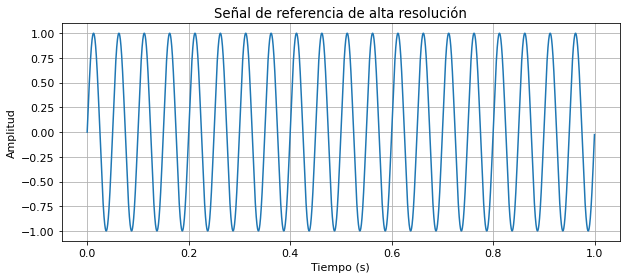

In [12]:
plt.figure()
plt.plot(t_ref, signal_ref)
plt.title("Señal de referencia de alta resolución")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.show()

## 3. Caso 1: muestreo claramente por encima de Nyquist

Se muestrea la señal con una frecuencia muy superior a \(2f_{\max}\). En este caso, el teorema de Shannon--Nyquist predice que la señal puede reconstruirse correctamente.

In [13]:
fs_high = 200
t_high = np.linspace(0, T, int(fs_high * T), endpoint=False)
signal_high = generate_sine(f_signal, t_high)

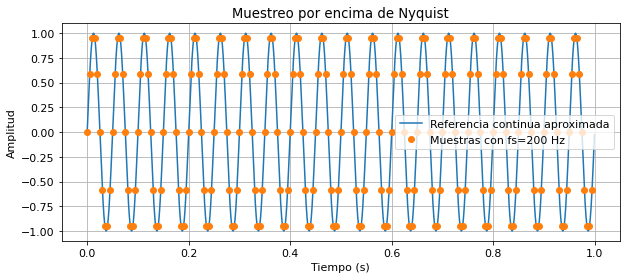

In [14]:
plt.figure()
plt.plot(t_ref, signal_ref, label="Referencia continua aproximada")
plt.plot(t_high, signal_high, "o", label=f"Muestras con fs={fs_high} Hz")
plt.title("Muestreo por encima de Nyquist")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

### Comentario

En este caso, las muestras capturan adecuadamente la oscilación de la señal, ya que la frecuencia de muestreo es muy superior al doble de la frecuencia presente. Por tanto, no aparece pérdida relevante de información estructural.

## 4. Caso 2: muestreo cercano al límite de Nyquist

Ahora se considera una frecuencia de muestreo próxima al umbral teórico \(2f_{\max}\). Este caso resulta interesante porque permite visualizar el comportamiento en una situación límite.

In [15]:
fs_nyquist = 45
t_nyquist = np.linspace(0, T, int(fs_nyquist * T), endpoint=False)
signal_nyquist = generate_sine(f_signal, t_nyquist)

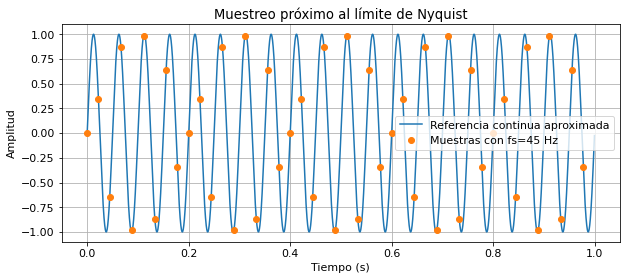

In [16]:
plt.figure()
plt.plot(t_ref, signal_ref, label="Referencia continua aproximada")
plt.plot(t_nyquist, signal_nyquist, "o", label=f"Muestras con fs={fs_nyquist} Hz")
plt.title("Muestreo próximo al límite de Nyquist")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

### Comentario

Aunque la señal sigue siendo reconocible, el muestreo es ya mucho más ajustado. Este caso muestra que, al aproximarse al límite de Nyquist, disminuye el margen de seguridad en la adquisición.

## 5. Caso 3: submuestreo por debajo de Nyquist

Finalmente, se estudia el caso en que la frecuencia de muestreo es inferior a \(2f_{\max}\). En este régimen, el teorema clásico deja de garantizar una reconstrucción correcta y aparece el fenómeno de aliasing.

In [17]:
fs_low = 25
t_low = np.linspace(0, T, int(fs_low * T), endpoint=False)
signal_low = generate_sine(f_signal, t_low)

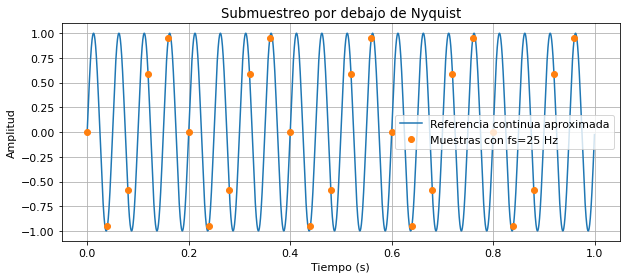

In [18]:
plt.figure()
plt.plot(t_ref, signal_ref, label="Referencia continua aproximada")
plt.plot(t_low, signal_low, "o", label=f"Muestras con fs={fs_low} Hz")
plt.title("Submuestreo por debajo de Nyquist")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.legend()
plt.show()

### Comentario

Aquí las muestras ya no capturan correctamente la oscilación real de la señal. Aunque los datos discretos parecen describir una señal coherente, la frecuencia observada a partir de ellos no coincide con la frecuencia verdadera. Esta ambigüedad es precisamente el aliasing.

## 6. Visualización en frecuencia de los tres casos

Se compara ahora el espectro de Fourier de las señales muestreadas en los tres regímenes anteriores.

In [19]:
freqs_high, fft_high = compute_fft(signal_high, fs_high)
freqs_nyquist, fft_nyquist = compute_fft(signal_nyquist, fs_nyquist)
freqs_low, fft_low = compute_fft(signal_low, fs_low)

mag_high = np.abs(fft_high) / len(signal_high)
mag_nyquist = np.abs(fft_nyquist) / len(signal_nyquist)
mag_low = np.abs(fft_low) / len(signal_low)

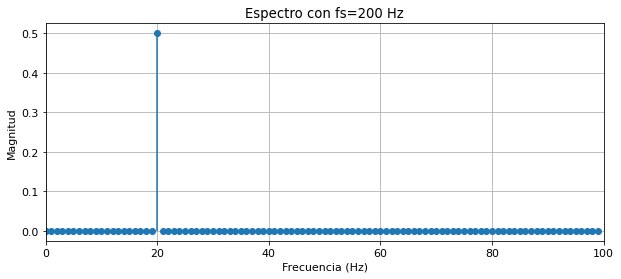

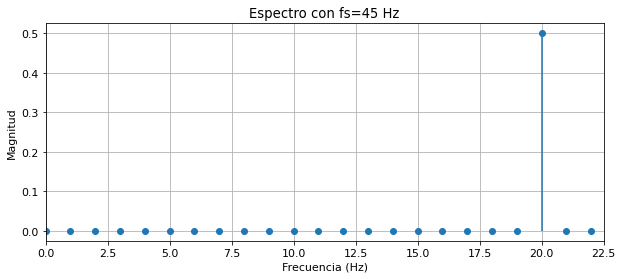

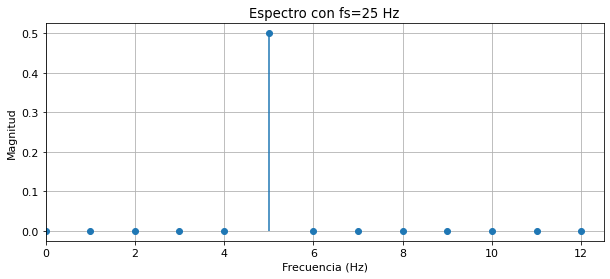

In [20]:
plt.figure()
plt.stem(freqs_high, mag_high, basefmt=" ")
plt.xlim(0, fs_high/2)
plt.title(f"Espectro con fs={fs_high} Hz")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

plt.figure()
plt.stem(freqs_nyquist, mag_nyquist, basefmt=" ")
plt.xlim(0, fs_nyquist/2)
plt.title(f"Espectro con fs={fs_nyquist} Hz")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

plt.figure()
plt.stem(freqs_low, mag_low, basefmt=" ")
plt.xlim(0, fs_low/2)
plt.title(f"Espectro con fs={fs_low} Hz")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.show()

### Interpretación

En los dos primeros casos, la frecuencia dominante sigue identificándose de forma coherente con la señal original. Sin embargo, en el caso de submuestreo, el espectro muestra una frecuencia aparente distinta de la real. Esto constituye una manifestación directa del aliasing en el dominio frecuencial.

## 7. Cálculo teórico de la frecuencia alias

Cuando la frecuencia de muestreo es insuficiente, una frecuencia real \(f\) puede observarse como una frecuencia alias \(f_a\) más baja dentro del intervalo visible. Este fenómeno puede analizarse también de forma cuantitativa.

In [21]:
def alias_frequency(f, fs):
    """
    Devuelve la frecuencia alias observada en [0, fs/2].
    """
    f_mod = f % fs
    if f_mod > fs / 2:
        return fs - f_mod
    return f_mod

f_alias = alias_frequency(f_signal, fs_low)

print(f"Frecuencia real: {f_signal} Hz")
print(f"Frecuencia de muestreo insuficiente: {fs_low} Hz")
print(f"Frecuencia alias observada: {f_alias} Hz")

Frecuencia real: 20 Hz
Frecuencia de muestreo insuficiente: 25 Hz
Frecuencia alias observada: 5 Hz


### Comentario

Este resultado cuantifica la ambigüedad introducida por el submuestreo. A partir de las muestras observadas, la señal parece contener una frecuencia distinta de la real, aunque los datos procedan de una señal perfectamente sinusoidal.

## 8. Comparación de varias frecuencias de muestreo

Para visualizar de forma más sistemática la transición entre muestreo correcto y submuestreo, se estudian varias frecuencias de muestreo y se representa la frecuencia aparente obtenida en cada caso.

In [22]:
fs_values = [15, 20, 25, 30, 35, 40, 45, 60, 100]
alias_values = [alias_frequency(f_signal, fs) for fs in fs_values]

for fs_val, alias_val in zip(fs_values, alias_values):
    print(f"fs = {fs_val:>3} Hz -> frecuencia observada = {alias_val:.2f} Hz")

fs =  15 Hz -> frecuencia observada = 5.00 Hz
fs =  20 Hz -> frecuencia observada = 0.00 Hz
fs =  25 Hz -> frecuencia observada = 5.00 Hz
fs =  30 Hz -> frecuencia observada = 10.00 Hz
fs =  35 Hz -> frecuencia observada = 15.00 Hz
fs =  40 Hz -> frecuencia observada = 20.00 Hz
fs =  45 Hz -> frecuencia observada = 20.00 Hz
fs =  60 Hz -> frecuencia observada = 20.00 Hz
fs = 100 Hz -> frecuencia observada = 20.00 Hz


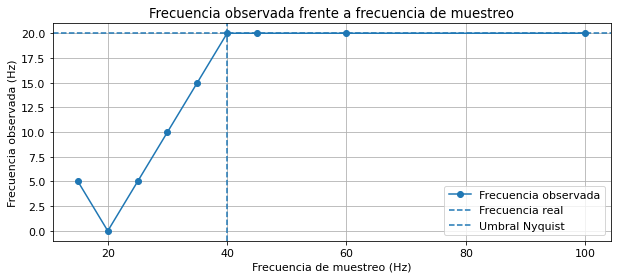

In [23]:
plt.figure()
plt.plot(fs_values, alias_values, marker="o", label="Frecuencia observada")
plt.axhline(y=f_signal, linestyle="--", label="Frecuencia real")
plt.axvline(x=2*f_signal, linestyle="--", label="Umbral Nyquist")
plt.title("Frecuencia observada frente a frecuencia de muestreo")
plt.xlabel("Frecuencia de muestreo (Hz)")
plt.ylabel("Frecuencia observada (Hz)")
plt.legend()
plt.show()

### (PARÉNTESIS) - Explicación simple un poco cutre para entender bien la gráfica:

-eje x: la frecuencia de muestreo fs, es decir, cuántas muestras por segundo tomas

-eje y: frecuencia que parece tener la señal cuando la observas con ese muestreo. (la señal que he creado yo es de 20hz, eso es la freuencia real)

(la línea vertical de 40 es 2*20 = 40, es decir el umbral de Nyquist)

¿Qué me esta diciendo la gráfica?

#### A LA DERECHA DE 40 HZ (Cuando muestreas con más de 40 Hz):

La frecuencia observada coincide con la real,o sea, ves correctamente los 20 Hz.
Por eso los puntos están en 20.

Interpretación - Aquí Shannon funciona bien:

-estás muestreando suficientemente rápido,
-no hay aliasing,
-no pierdes la información frecuencial principal.

#### A LA IZQ DE 40 HZ (Cuando muestreas por debajo de 40 Hz):

la frecuencia observada ya no coincide con la real, aparece otra frecuencia “falsa” - esa frecuencia falsa es el alias.
Por eso los puntos ya no están en 20.

Interpretación - Aquí ya no puedes distinguir correctamente la señal real a partir de las muestras.
La señal de 20 Hz se “disfraza” de otra más baja.
Eso es exactamente el aliasing.

![Aliasing](images/aliasing.png)

### Interpretación

Se observa que, cuando la frecuencia de muestreo supera el umbral de Nyquist, la frecuencia observada coincide con la real. Por debajo de dicho umbral, aparece una discrepancia sistemática debida al aliasing. Esta transición experimental refleja con claridad el contenido del teorema de Shannon--Nyquist.

## 9. Conclusiones del notebook

Los experimentos realizados permiten extraer las siguientes conclusiones:

1. la posibilidad de reconstruir correctamente una señal depende de la relación entre su contenido frecuencial y la frecuencia de muestreo;
2. cuando la frecuencia de muestreo supera el doble de la frecuencia máxima presente, la señal queda correctamente representada en sus muestras;
3. cuando esta condición no se cumple, aparecen ambigüedades y aliasing;
4. por tanto, el paradigma clásico de reconstrucción exige una condición mínima de adquisición ligada al ancho de banda de la señal.

Este resultado es esencial en el TFG porque muestra la limitación fundamental del muestreo clásico y justifica la búsqueda de estrategias alternativas cuando la señal posee estructura adicional, como dispersidad en una base adecuada.